## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "physbo_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "/Users/shibukawar/workspace/nimo-fork/multi_batch_experiments_melting_temperature/./configs/physbo_batch1_trial5.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = config["batch_size"]
TOTAL_EVAL = config["total_eval"]
INITIAL_BATCH_SIZE = config["initial_batch_size"]
print(f"Initial Batch Size: {INITIAL_BATCH_SIZE}")
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

# Create output directory with batch size in name
out_dir = Path(f"./data_physbo_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

Initial Batch Size: 15
CyclesNum: 30


PosixPath('data_physbo_batch1_trial5/physbo_batch1_trial5.yaml')

In [9]:
candidates_file = out_dir / f"mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"mp_proposals_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "PHYSBO",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_melting_point
    analysis_output_functions_SO_melting_point.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")
end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  435
proposal =  [18. 24.]
###
###
number = 2
actions =  647
proposal =  [28. 48.]
###
###
number = 3
actions =  1011
proposal =  [52. 20.]
###
###
number = 4
actions =  397
proposal =  [16. 34.]
###
###
number = 5
actions =  814
proposal =  [38. 32.]
###
###
number = 6
actions =  853
proposal =  [40. 46.]
###
###
number = 7
actions =  1263
proposal =  [80.  6.]
###
###
number = 8
actions =  347
proposal =  [14. 22.]
###
###
number = 9
actions =  1289
proposal =  [84. 16.]
###
###
number = 10
actions =  396
proposal =  [16. 32.]
###
###
number = 11
actions =  863
proposal =  [42.  4.]
###
###
number = 12
actions =  1145
proposal =  [64. 18.]
###
###
number = 13
actions =  470
proposal =  [20. 10.]
###
###
number = 14
actions =  375
proposal =  [14. 78.]
###
###
number = 15
actions =  948
proposal =  [48.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!

Start selection of proposals by PHYSBO!
1808365797
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 72.8174524547553
50 -th epoch marginal likelihood 72.65932815261266
100 -th epoch marginal likelihood 72.54544257319289
150 -th epoch marginal likelihood 72.47041031886233
200 -th epoch marginal likelihood 72.41988450298926
250 -th epoch marginal likelihood 72.38091784632773
300 -th epoch marginal likelihood 72.34688424265906
350 -th epoch marginal likelihood 72.3156319709753
400 -th epoch marginal likelihood 72.28660026963837
450 -th epoch marginal likelihood 72.25957966984764


500 -th epoch marginal likelihood 72.2344246785607
Done

Proposals
###
number = 1
actions =  1295
proposal =  [86. 10.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
1005923258
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 78.00401737436432
50 -th epoch marginal likelihood 77.62466787477315
100 -th epoch marginal likelihood 77.33890153253122
150 -th epoch marginal likelihood 77.10675821227454
200 -th epoch marginal likelihood 76.90476206487861
250 -th epoch marginal likelihood 76.73188063688302
300 -th epoch marginal likelihood 76.59038700419293
350 -th epoch marginal likelihood 76.47960667696606
400 -th epoch marginal likelihood 76.39570422012018
450 -th epoch marginal likelihood 76.33297829498125


...

Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 198.66787593555287
50 -th epoch marginal likelihood 196.7016660661178
100 -th epoch marginal likelihood 195.15770455239957
150 -th epoch marginal likelihood 193.87871028527832
200 -th epoch marginal likelihood 192.8365257061989
250 -th epoch marginal likelihood 192.0111833527923
300 -th epoch marginal likelihood 191.35263468113536
350 -th epoch marginal likelihood 190.80307920489884


400 -th epoch marginal likelihood 190.31570491448787
450 -th epoch marginal likelihood 189.86087710772918
500 -th epoch marginal likelihood 189.42330022748757
Done

Proposals
###
number = 1
actions =  974
proposal =  [48. 52.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
653943327
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 205.69443620601243
50 -th epoch marginal likelihood 203.28109277735348
100 -th epoch marginal likelihood 201.1926342914538
150 -th epoch marginal likelihood 199.44514066331465
200 -th epoch marginal likelihood 197.98856370714708
250 -th epoch marginal likelihood 196.77378150236598
300 -th epoch marginal likelihood 195.77302349860634
350 -th epoch marginal likelihood 194.9563649832792


400 -th epoch marginal likelihood 194.28391031075438
450 -th epoch marginal likelihood 193.714248661239
500 -th epoch marginal likelihood 193.21279510722744
Done

Proposals
###
number = 1
actions =  545
proposal =  [22. 78.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!


Elapsed time: 81.13977527618408 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


Text(0, 0.5, 'Objective')

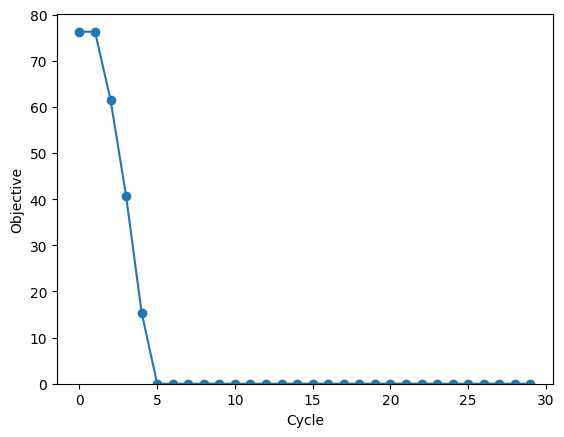

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)